In [1]:
import sklearn
print(sklearn.__version__)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Other plots (example)

from src.exp import (
    ExperimentConfig, ExperimentFacade,
    DataReadConfig, PlotManager
)

1.8.0


In [2]:
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("Intel sklearn patch enabled")
except ImportError:
    print("sklearnex not installed; using standard sklearn")


sklearnex not installed; using standard sklearn


In [3]:
data_cfg = DataReadConfig(
    root_dir="Dataset/data",
    recursive=True,
    exclude_filenames=["cclass.csv", "unclean focus.csv","unclean cclass.csv","focus.csv"],  # the excluded files
    add_source_column=False,        # enable this to make additional column filled with the original taken filenames
)

In [4]:
cfg = ExperimentConfig(
    outer_folds=5,
    inner_folds=5,
    n_trials=40,
    seed=42,
    log_target=True
)

In [5]:
models = ["SVR", "NeuralNetwork"] #["LinearRegression", "DecisionTree", "RandomForest", "SVR", "XGBoost", "NeuralNetwork"]

In [6]:
exp = ExperimentFacade.from_folder(
    data_cfg=data_cfg,
    target="price",
    cfg=cfg,
    model_names=models,
    hparam_json="config/hyperparams.json"
)

# model, year, price, transmission, mileage, fuelType, tax, mpg, engineSize

[schema]
  numerical cols: ['year', 'mileage', 'tax', 'mpg', 'engineSize']
  categorical cols: ['model', 'transmission', 'fuelType']
  target col: ['price']
  mapping: {'model': 'model', 'year': 'year', 'price': 'price', 'transmission': 'transmission', 'mileage': 'mileage', 'fuelType': 'fuelType', 'tax': 'tax', 'mpg': 'mpg', 'engineSize': 'engineSize'}


In [7]:
results = exp.run()

[I 2026-01-31 05:54:17,454] A new study created in memory with name: SVR_OuterFold_1_residual_cfg_base
[I 2026-01-31 05:55:05,953] Trial 0 finished with value: 0.907967141361623 and parameters: {'C': 20, 'gamma': 0.3735197210896576, 'epsilon': 0.2872375301687824}. Best is trial 0 with value: 0.907967141361623.
[I 2026-01-31 05:56:42,293] Trial 1 finished with value: 0.9108377523692454 and parameters: {'C': 10, 'gamma': 0.4655457962128, 'epsilon': 0.24858505247704815}. Best is trial 1 with value: 0.9108377523692454.
[I 2026-01-31 06:15:14,703] Trial 2 finished with value: 0.9165045404558374 and parameters: {'C': 20, 'gamma': 0.39727767795160035, 'epsilon': 0.13272305141483834}. Best is trial 2 with value: 0.9165045404558374.
[I 2026-01-31 06:25:52,620] Trial 3 finished with value: 0.9147162932220146 and parameters: {'C': 20, 'gamma': 0.29349377934107995, 'epsilon': 0.13809291831580145}. Best is trial 2 with value: 0.9165045404558374.
[I 2026-01-31 06:25:54,597] Trial 4 finished with val

496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 242us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 237us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 235us/step


[I 2026-01-31 06:43:09,974] Trial 0 finished with value: -98677809.92136827 and parameters: {'optimizer': 'adamW', 'n_layers': 2, 'units_layer_1': 93, 'units_layer_2': 182, 'units_layer_3': 120, 'units_layer_4': 95, 'activation': 'relu', 'learning_rate': 0.008912031574631267, 'momentum': 0.4442189556872475, 'weight_decay': 2.6333841844193604e-06}. Best is trial 0 with value: -98677809.92136827.


496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step


[I 2026-01-31 06:45:47,316] Trial 1 finished with value: 0.8706927296036129 and parameters: {'optimizer': 'sgd', 'n_layers': 3, 'units_layer_1': 90, 'units_layer_2': 156, 'units_layer_3': 123, 'units_layer_4': 63, 'activation': 'sigmoid', 'learning_rate': 0.009308155018643535, 'momentum': 0.21940831436629465, 'weight_decay': 1.955409609247652e-06}. Best is trial 1 with value: 0.8706927296036129.


...

496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step


[I 2026-01-31 13:46:44,770] Trial 11 finished with value: 0.11896564649097074 and parameters: {'optimizer': 'adamW', 'n_layers': 4, 'units_layer_1': 238, 'units_layer_2': 36, 'units_layer_3': 126, 'units_layer_4': 207, 'activation': 'gelu', 'learning_rate': 0.0006857673031099295, 'momentum': 0.9089851574224532, 'weight_decay': 1.1874977531596009e-05}. Best is trial 1 with value: 0.9049584748958258.


496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step


[I 2026-01-31 13:53:22,073] Trial 12 finished with value: -14.066845960656295 and parameters: {'optimizer': 'rmsprop', 'n_layers': 3, 'units_layer_1': 160, 'units_layer_2': 101, 'units_layer_3': 161, 'units_layer_4': 230, 'activation': 'gelu', 'learning_rate': 0.00040426390469668066, 'momentum': 0.6434681727307702, 'weight_decay': 1.2345345401133665e-05}. Best is trial 1 with value: 0.9049584748958258.


620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/hyperparameters/best_hyperparameters.json
[final fit] SVR
[saved] SVR
[final fit] NeuralNetwork
[saved] NeuralNetwork


In [14]:
display(exp.summary())


,model,R2_mean,R2_std,MAE_mean,MAE_std,MedAE_mean,MedAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std
0,NeuralNetwork,0.857367,0.101190,1797.643799,57.586367,1123.053418,69.141128,1.390954e+07,9.936409e+06,3586.247052,1144.753767
1,SVR,0.918278,0.008758,1690.674186,38.772441,1100.146657,23.547407,7.955669e+06,8.731678e+05,2817.160278,155.228273


In [15]:
sig = exp.significance(
    metric="R2",
    baseline="SVR",
    models=["NeuralNetwork"]
)

In [16]:
display(sig)

,metric,baseline,model,paired_t_p,wilcoxon_p,n_outer_folds
0,R2,SVR,NeuralNetwork,0.247226,0.0625,5


In [17]:
shap_analyzer = exp.shap(models=models)

Computing SHAP for SVR:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/shap/shap_beeswarm_svr.png


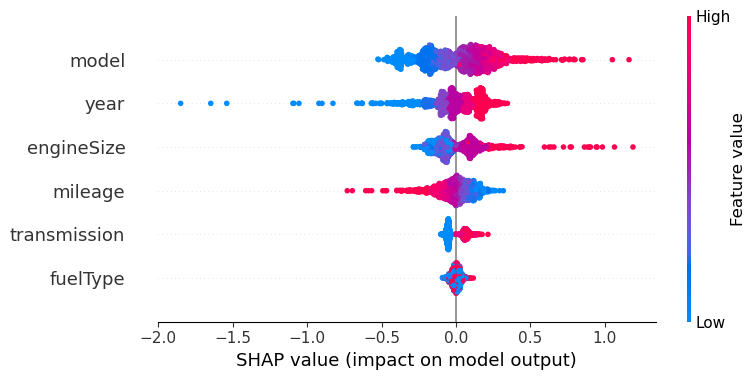

Computing SHAP for NeuralNetwork:   0%|          | 0/5 [00:00<?, ?it/s]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


  0%|          | 0/300 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2

  0%|          | 0/300 [00:00<?, ?it/s]

...

  0%|          | 0/300 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

  0%|          | 0/300 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

<Figure size 1000x600 with 0 Axes>

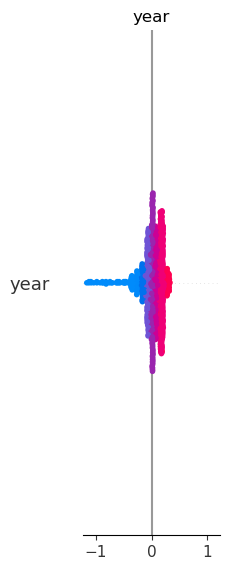

In [13]:
for m in shap_analyzer.available_models():
    shap_analyzer.beeswarm(m)

In [ ]:
exp.summary()

,model,R2_mean,R2_std,MAE_mean,MAE_std,MedAE_mean,MedAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std
0,RandomForest+PseudoHuber,0.954636,0.004347,1213.178533,27.572292,764.550687,20.871401,4.412990e+06,394806.898976,2099.003759,94.693544
1,XGBoost+Huber,0.956735,0.005037,1162.554695,33.071310,740.210750,21.053388,4.213966e+06,518182.709471,2049.638215,127.226374


In [ ]:
results.to_csv("outputs/experiment_results.csv", index=False)

In [19]:
pm = PlotManager("outputs/figures/metrics")

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_r2.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_mae.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_medae.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_mse.png
[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/metrics/point_range_rmse.png


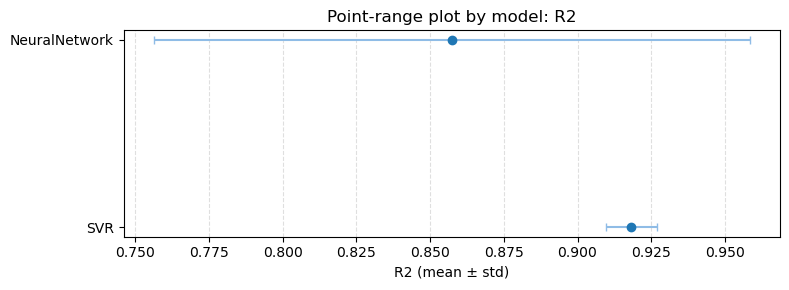

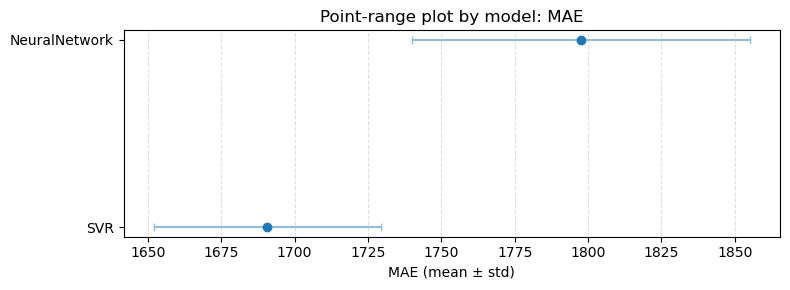

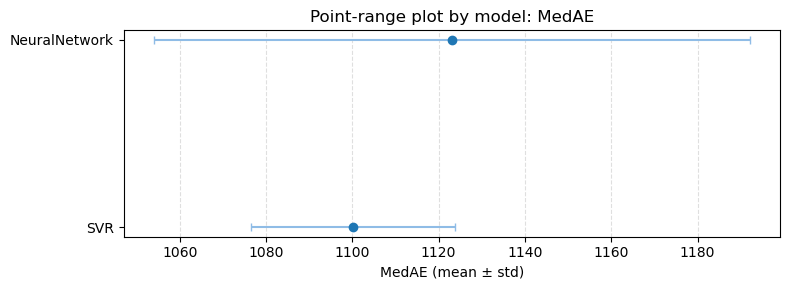

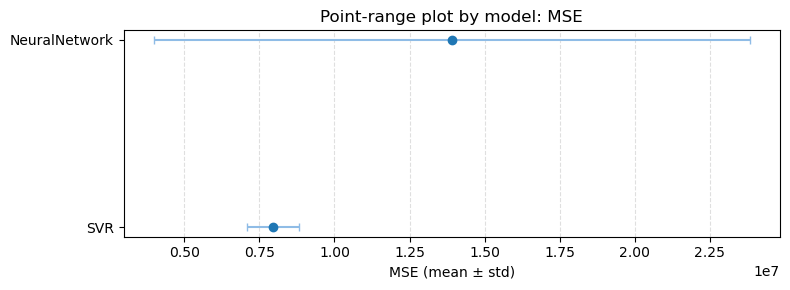

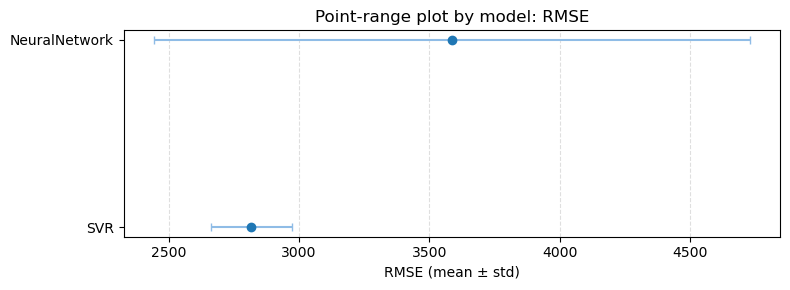

In [20]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    is_ascending = metric != "R2" and metric != "NegMSE"
    #fig = plot_point_range_1(results, metric=metric, ascending=is_ascending)
    #fig.savefig(f"outputs/figures/metrics/point_range_{metric.lower()}", dpi=300, bbox_inches="tight")
    fig = pm.plot_point_range(results_df=results, metric=metric, ascending=is_ascending)
    pm.save_fig(fig, f"point_range_{metric.lower()}")

In [ ]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    display(exp.significance_matrix(metric=metric))

,metric,model_a,model_b,paired_t_p,wilcoxon_p,n_outer_folds
0,R2,RandomForest+PseudoHuber,XGBoost+Huber,0.248926,0.3125,5


In [ ]:
exp.save_best_params()

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/best_params/best_params.json
